# Compare contact configurations

Load any explicitly selected result configurations and overlay their trajectories to get a direct comparison. Add another label/path entry to `RESULT_FOLDERS` to include a new configuration.

In [ ]:
from pathlib import Path
import os
import re
import sys
import cloudpickle
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# Make the notebook work whether Jupyter starts in the repository root or notebooks/.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'visualize_walking2d.py').exists()), None)
if ROOT is None:
    raise RuntimeError('Could not locate the ideal-treadmill-biosym repository root.')
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from biosym.model import model as biosym_model_module
from src.contact_huntcrossley import install as install_huntcrossley
from src.sliding_huntcrossley import install as install_sliding
from src.gait_data import DEFAULT_GAIT_DATA_FILE, get_belt_speeds, get_duration, get_grfs
from visualize_walking2d import evaluate_contact_diagnostics, load_model_with_treadmill_contact

jax.config.update('jax_enable_x64', True)
install_huntcrossley()
install_sliding()
plt.rcParams['figure.dpi'] = 120

PARTICIPANT = 1
# Only entries in this mapping are compared. Add a label/path pair for each new config.
RESULT_FOLDERS = {
    '<Name1>': Path('<Path_to_Result_Folder1>'),
    '<Name2>': Path('<Path_to_Result_Folder2>'),
    '<Name3>': Path('<Path_to_Result_Folder3>'),
}
RESULT_FOLDERS

{'e300_grf2e3': PosixPath('result_HC/p3/huntcrossley_6spheres/0814_e300_grf2e3'),
 'e300_grf3e3': PosixPath('result_HC/p3/huntcrossley_6spheres/0814_e300_grf3e3'),
 'e300_grf5e3': PosixPath('result_HC/p3/huntcrossley_6spheres/0814_e300_grf5e3'),
 'e300_grf7e3': PosixPath('result_HC/p3/huntcrossley_6spheres/0814_e300_grf7e3'),
 'e300_grf10e3': PosixPath('result_HC/p3/huntcrossley_6spheres/0814_e300_grf10e3'),
 'e300_grf20e3': PosixPath('result_HC/p3/huntcrossley_6spheres/0814_e300_grf20e3')}

## Load and index results

In [15]:
RESULT_RE = re.compile(r'^(overground|treadmill_ideal|treadmill_realistic|treadmill_fixed|treadmill_real)_(\d+)_(\d+)\.pkl$')

def parse_result_path(path):
    match = RESULT_RE.match(path.name)
    if not match:
        return None
    stage, whole, decimal = match.groups()
    stage = {
        'treadmill_fixed': 'treadmill_ideal',
        'treadmill_real': 'treadmill_realistic',
    }.get(stage, stage)
    return stage, float(f'{whole}.{decimal}')

def load_result(path):
    with path.open('rb') as handle:
        payload = cloudpickle.load(handle)
    if len(payload) == 3:
        (states, globals_), info, settings = payload
    elif len(payload) == 2:
        (states, globals_), info = payload
        settings = {}
    else:
        raise ValueError(f'Unexpected result structure in {path}')
    return {'states': states, 'globals': globals_, 'info': info, 'settings': settings, 'path': path}

records = []
for configuration, folder in RESULT_FOLDERS.items():
    if not folder.exists():
        print(f'Warning: missing folder: {folder}')
        continue
    for path in sorted(folder.glob('*.pkl')):
        parsed = parse_result_path(path)
        if parsed is None:
            continue
        stage, speed = parsed
        records.append({'configuration': configuration, 'stage': stage, 'speed': speed, **load_result(path)})

results = pd.DataFrame(records)
results[['configuration', 'stage', 'speed', 'path']].sort_values(['speed', 'stage', 'configuration'])

,configuration,stage,speed,path
20,e300_grf10e3,treadmill_ideal,1.0,result_HC/p3/huntcrossley_6spheres/0814_e300_g...
25,e300_grf20e3,treadmill_ideal,1.0,result_HC/p3/huntcrossley_6spheres/0814_e300_g...
0,e300_grf2e3,treadmill_ideal,1.0,result_HC/p3/huntcrossley_6spheres/0814_e300_g...
5,e300_grf3e3,treadmill_ideal,1.0,result_HC/p3/huntcrossley_6spheres/0814_e300_g...
10,e300_grf5e3,treadmill_ideal,1.0,result_HC/p3/huntcrossley_6spheres/0814_e300_g...
15,e300_grf7e3,treadmill_ideal,1.0,result_HC/p3/huntcrossley_6spheres/0814_e300_g...
21,e300_grf10e3,treadmill_ideal,1.2,result_HC/p3/huntcrossley_6spheres/0814_e300_g...
26,e300_grf20e3,treadmill_ideal,1.2,result_HC/p3/huntcrossley_6spheres/0814_e300_g...
1,e300_grf2e3,treadmill_ideal,1.2,result_HC/p3/huntcrossley_6spheres/0814_e300_g...
6,e300_grf3e3,treadmill_ideal,1.2,result_HC/p3/huntcrossley_6spheres/0814_e300_g...


In [16]:
_model_cache = {}

def model_path_from_record(record):
    settings = record['settings']
    path = settings.get('settings', {}).get('model')
    if path is None:
        raise KeyError(f"No model path stored in {record['path']}")
    return str(path)

def get_model(record):
    path = model_path_from_record(record)
    is_treadmill = record['stage'] in ('treadmill_ideal', 'treadmill_realistic')
    key = (path, is_treadmill)
    if key not in _model_cache:
        if is_treadmill:
            _model_cache[key] = load_model_with_treadmill_contact(
                model_file=path, force_rebuild=False
            )
        else:
            _model_cache[key] = biosym_model_module.load_model(path, force_rebuild=False)
    return _model_cache[key]

def contact_forces(record):
    model = get_model(record)
    states = record['states']
    def force_at_node(state):
        full = state.replace(
            qdd=jnp.zeros(model.accs.n),
            tau=jnp.zeros(model.tau.n),
            ext_forces=jnp.zeros(model.ext_forces.n),
            ext_torques=jnp.zeros(model.ext_torques.n),
        )
        return model.run['gc_model'](full, model.default_constants)[0]
    return np.asarray(jax.vmap(force_at_node)(states))

def gait_cycle(n):
    return np.linspace(0, 100, n)

def select(stage, speed):
    return results[(results.stage == stage) & np.isclose(results.speed, speed)]


def configuration_colors():
    names = list(RESULT_FOLDERS)
    cmap = plt.colormaps.get_cmap('turbo').resampled(max(len(names), 1))
    return {name: cmap(index) for index, name in enumerate(names)}

print('Available stages:', sorted(results.stage.unique()))
print('Available speeds:', sorted(results.speed.unique()))

Available stages: ['treadmill_ideal']
Available speeds: [np.float64(1.0), np.float64(1.2), np.float64(1.4), np.float64(1.6), np.float64(1.8)]


## Summary overlay

Choose one stage and speed. Solid colored lines are simulations; dotted black lines are experimental data.

Loading model from cache: a087d0f7631b27fde5358afd3027dbb45789263a81261b75159542168009932a_x64_eom_nomusclefit.cpkl


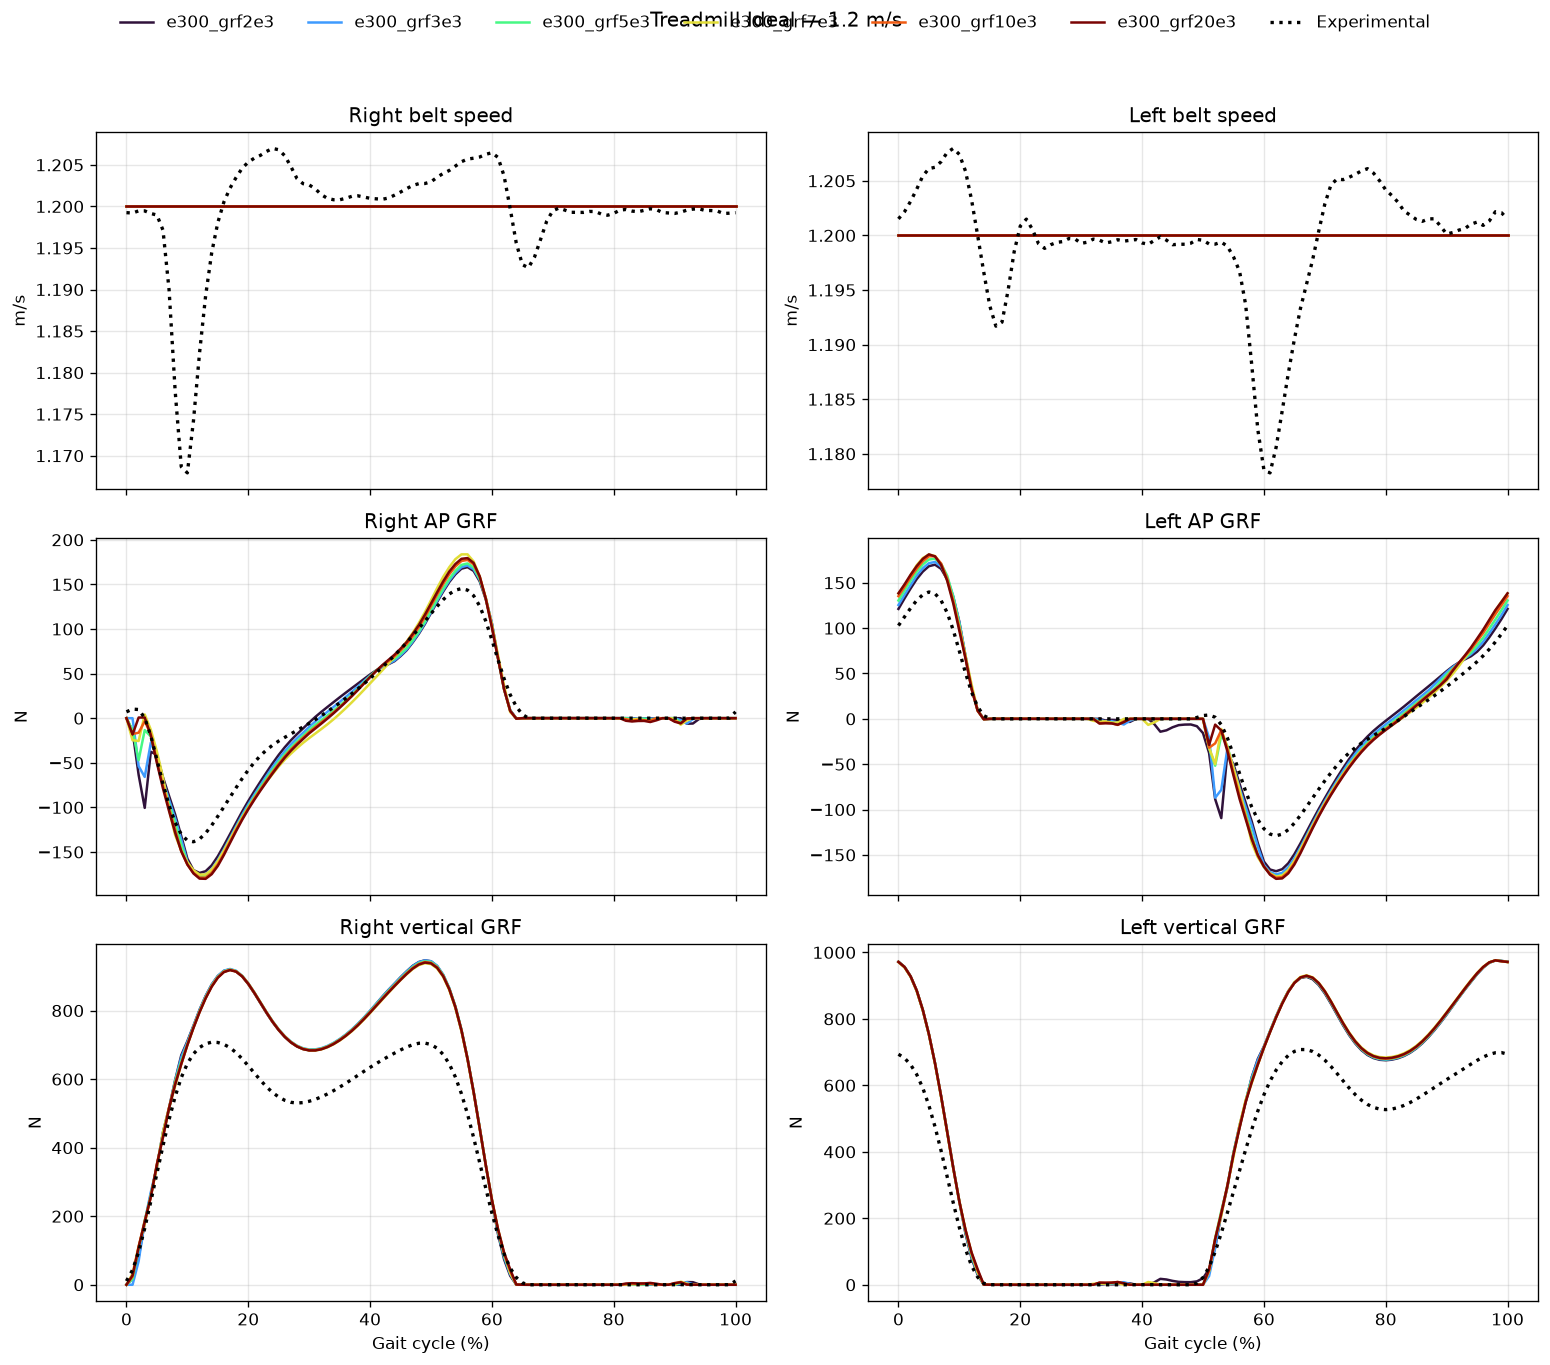

In [17]:
STAGE = 'treadmill_ideal'
SPEED = 1.2

def plot_summary_overlay(stage, speed):
    chosen = select(stage, speed)
    if chosen.empty:
        raise ValueError(f'No results for {stage=} and {speed=}')
    colors = configuration_colors()
    fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
    axes = axes.ravel()
    for _, record in chosen.iterrows():
        label = record.configuration
        color = colors[label]
        states = record.states
        forces = contact_forces(record)
        x = gait_cycle(len(states))
        treadmill = np.asarray(states.gc_model)
        if treadmill.ndim == 2 and treadmill.shape[1] >= 2:
            axes[0].plot(x, -treadmill[:, 0], color=color, label=label)
            axes[1].plot(x, -treadmill[:, 1], color=color, label=label)
        else:
            axes[0].plot(x, np.zeros_like(x), color=color, label=label)
            axes[1].plot(x, np.zeros_like(x), color=color, label=label)
        axes[2].plot(x, forces[:, 0, 0], color=color, label=label)
        axes[3].plot(x, forces[:, 1, 0], color=color, label=label)
        axes[4].plot(x, forces[:, 0, 1], color=color, label=label)
        axes[5].plot(x, forces[:, 1, 1], color=color, label=label)

    n = len(chosen.iloc[0].states)
    exp_belt = get_belt_speeds(DEFAULT_GAIT_DATA_FILE, PARTICIPANT, speed, n)
    exp_grf = get_grfs(DEFAULT_GAIT_DATA_FILE, PARTICIPANT, speed, n)
    x = gait_cycle(n)
    for axis, values in zip(axes, [exp_belt['right'], exp_belt['left'], exp_grf['fx_r'], exp_grf['fx_l'], exp_grf['fy_r'], exp_grf['fy_l']]):
        axis.plot(x, values, ':', color='black', linewidth=2, label='Experimental')
    titles = ['Right belt speed', 'Left belt speed', 'Right AP GRF', 'Left AP GRF', 'Right vertical GRF', 'Left vertical GRF']
    ylabels = ['m/s', 'm/s', 'N', 'N', 'N', 'N']
    for axis, title, ylabel in zip(axes, titles, ylabels):
        axis.set_title(title); axis.set_ylabel(ylabel); axis.grid(alpha=.3)
    axes[-2].set_xlabel('Gait cycle (%)'); axes[-1].set_xlabel('Gait cycle (%)')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='outside upper center', ncol=len(labels), frameon=False)
    fig.suptitle(f'{stage.replace("_", " ").title()} — {speed:.1f} m/s', y=1.03)
    fig.tight_layout()
    return fig

plot_summary_overlay(STAGE, SPEED);

## AP and vertical GRF overlay

AP and vertical ground-reaction forces are shown on separate axes. Colors identify contact configurations; solid and dashed lines identify the right and left sides.

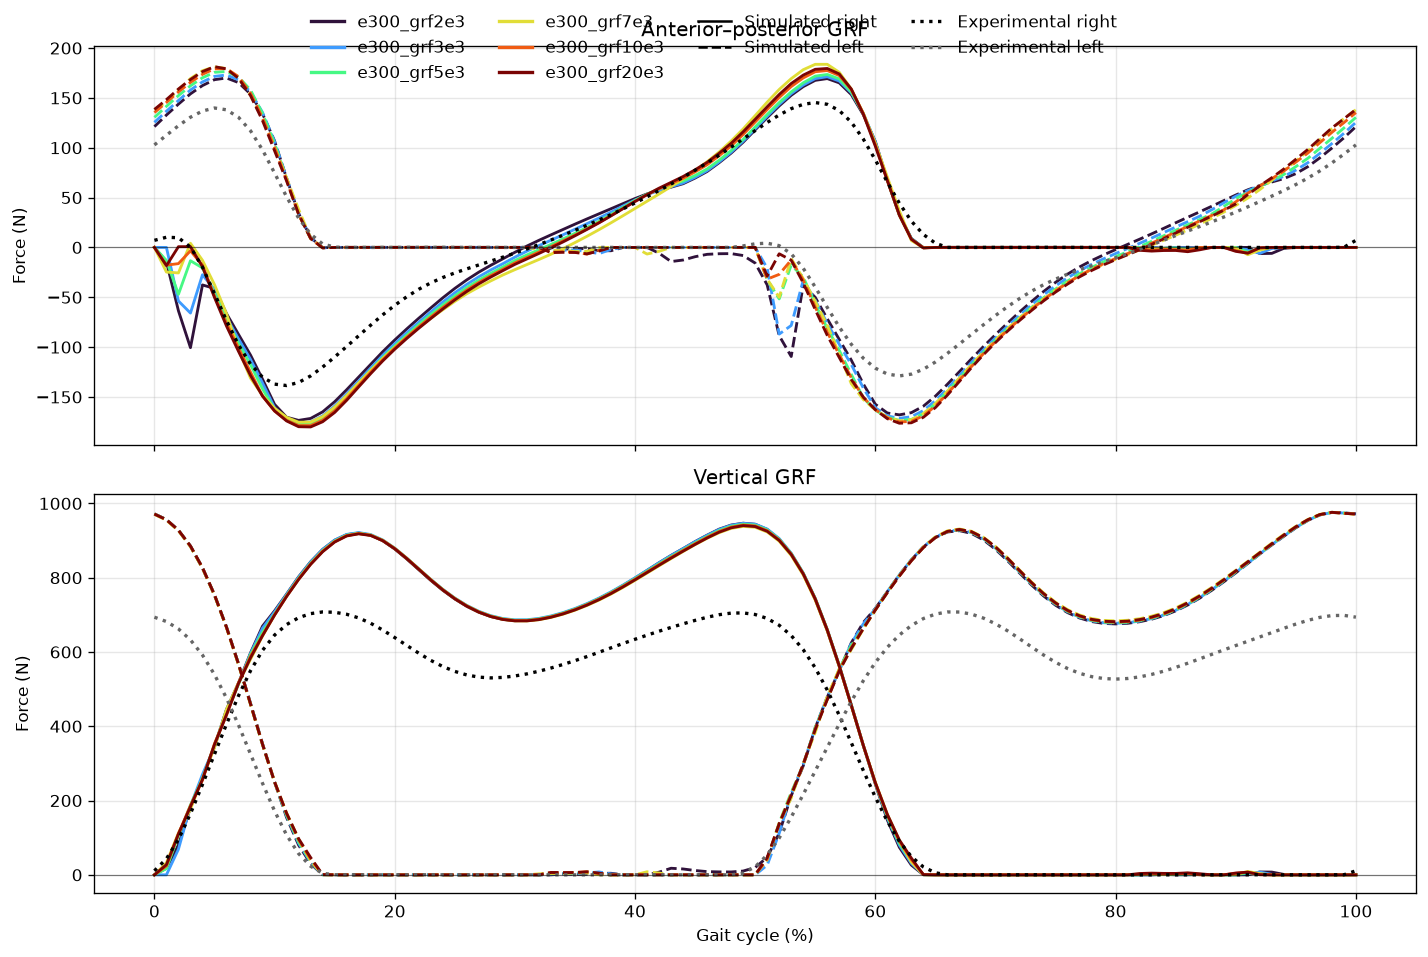

In [18]:
def plot_grf_components(stage, speed):
    chosen = select(stage, speed)
    if chosen.empty:
        raise ValueError(f'No results for {stage=} and {speed=}')
    colors = configuration_colors()
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    for _, record in chosen.iterrows():
        forces = contact_forces(record)
        x = gait_cycle(len(forces))
        color = colors[record.configuration]
        axes[0].plot(x, forces[:, 0, 0], color=color, linestyle='-', linewidth=1.7)
        axes[0].plot(x, forces[:, 1, 0], color=color, linestyle='--', linewidth=1.7)
        axes[1].plot(x, forces[:, 0, 1], color=color, linestyle='-', linewidth=1.7)
        axes[1].plot(x, forces[:, 1, 1], color=color, linestyle='--', linewidth=1.7)

    n = len(chosen.iloc[0].states)
    experimental = get_grfs(DEFAULT_GAIT_DATA_FILE, PARTICIPANT, speed, n)
    x = gait_cycle(n)
    axes[0].plot(x, experimental['fx_r'], color='black', linestyle=':', linewidth=2)
    axes[0].plot(x, experimental['fx_l'], color='0.4', linestyle=':', linewidth=2)
    axes[1].plot(x, experimental['fy_r'], color='black', linestyle=':', linewidth=2)
    axes[1].plot(x, experimental['fy_l'], color='0.4', linestyle=':', linewidth=2)

    axes[0].set_title('Anterior–posterior GRF')
    axes[1].set_title('Vertical GRF')
    for axis in axes:
        axis.set_ylabel('Force (N)')
        axis.axhline(0, color='black', linewidth=.7, alpha=.5)
        axis.grid(alpha=.3)
    axes[1].set_xlabel('Gait cycle (%)')

    configuration_handles = [
        Line2D([0], [0], color=colors[name], lw=2, label=name)
        for name in chosen.configuration.unique()
    ]
    style_handles = [
        Line2D([0], [0], color='black', linestyle='-', label='Simulated right'),
        Line2D([0], [0], color='black', linestyle='--', label='Simulated left'),
        Line2D([0], [0], color='black', linestyle=':', linewidth=2, label='Experimental right'),
        Line2D([0], [0], color='0.4', linestyle=':', linewidth=2, label='Experimental left'),
    ]
    fig.legend(
        handles=configuration_handles + style_handles,
        loc='outside upper center', ncol=4, frameon=False,
    )
    title = stage.replace('_', ' ').title()
    #fig.suptitle(f'Ground-reaction forces — {title} — {speed:.1f} m/s', y=1.04)
    fig.tight_layout()
    return fig

plot_grf_components(STAGE, SPEED);

## Joint-angle overlay

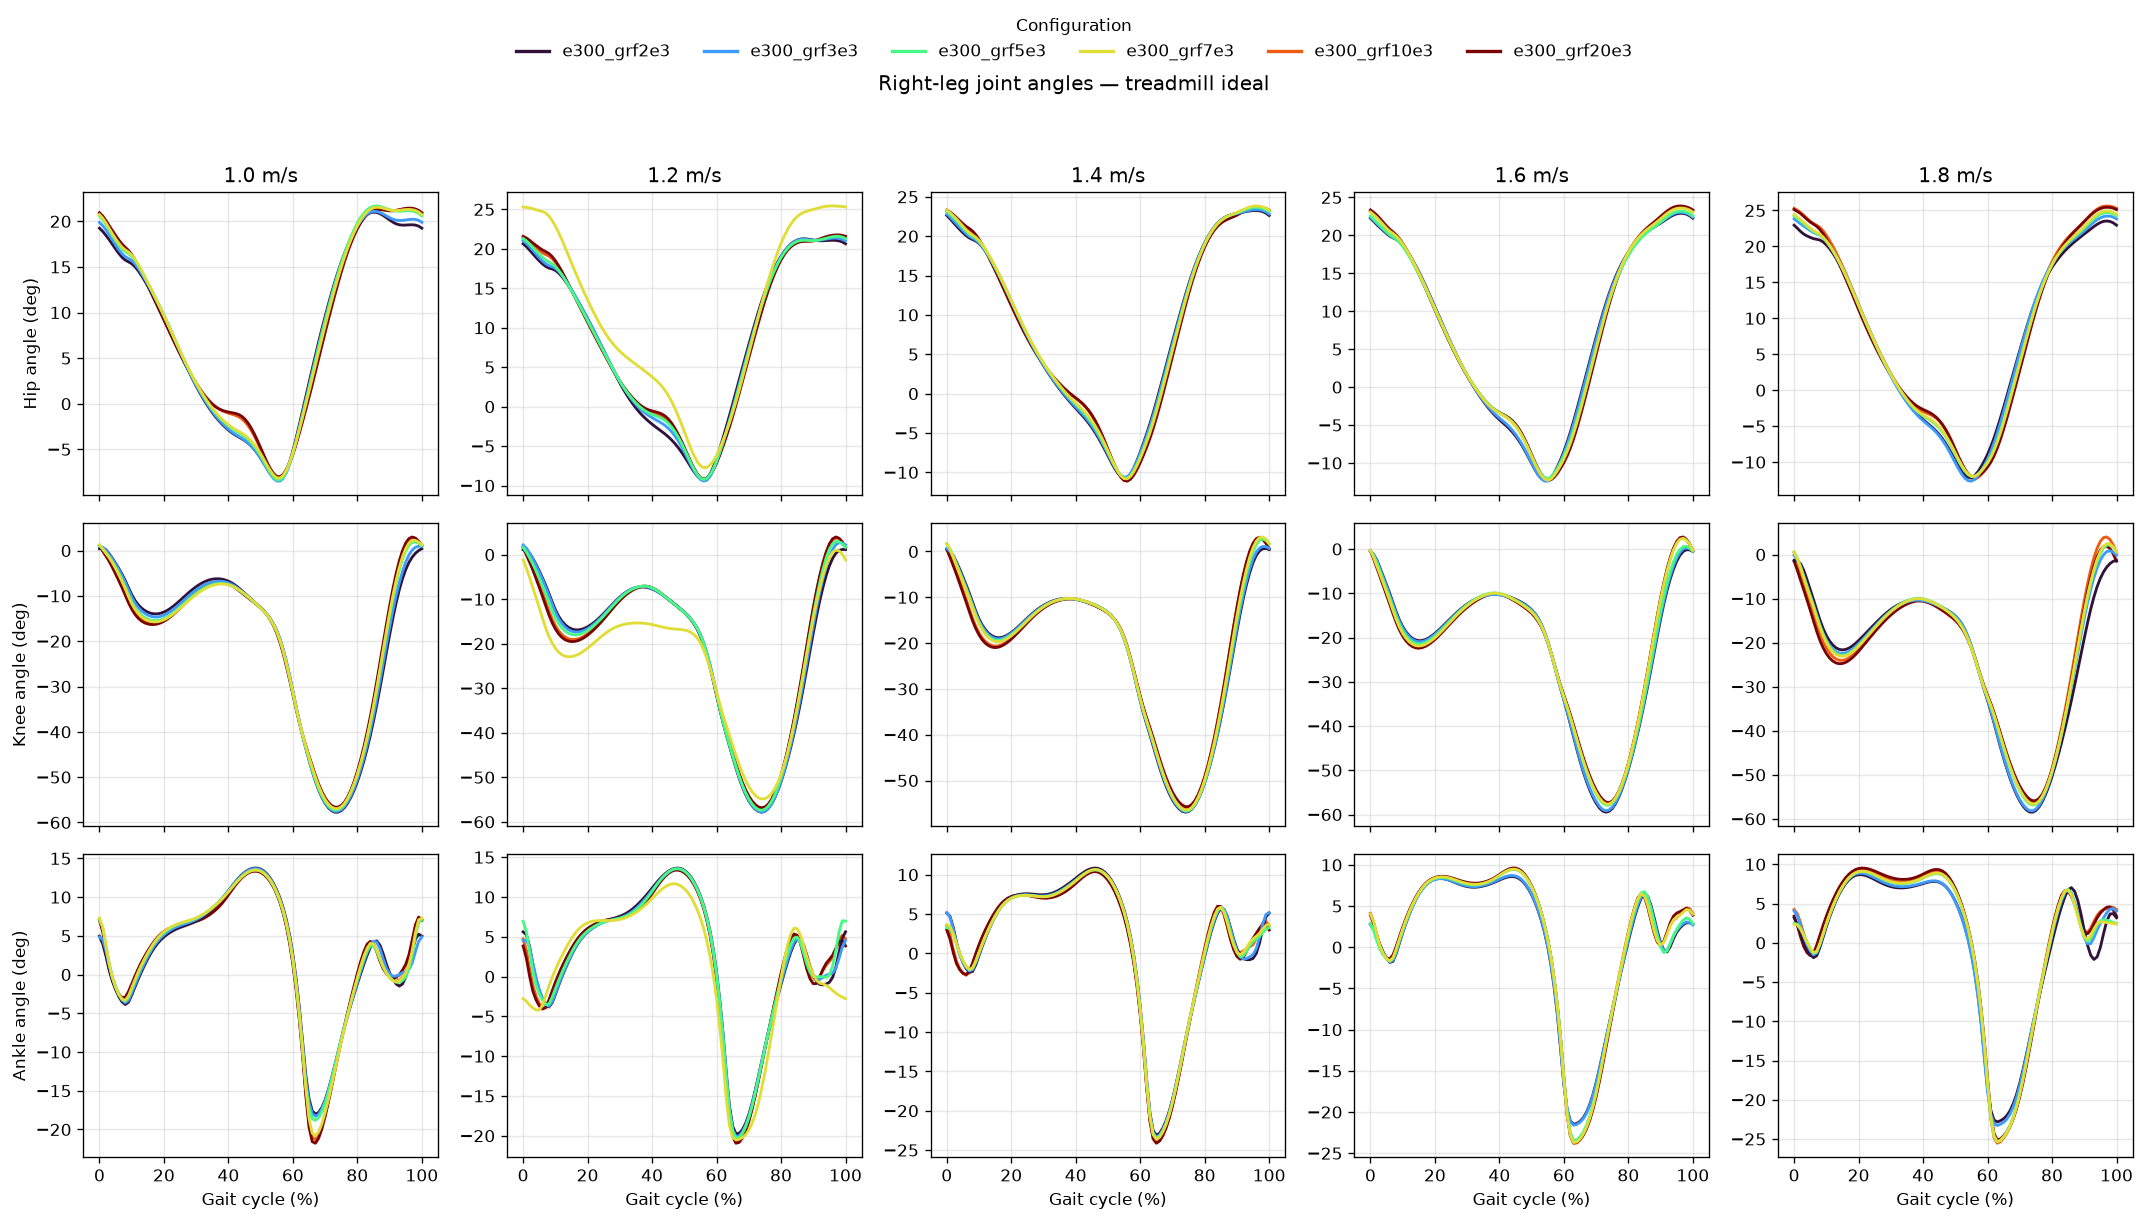

In [20]:
def coordinate_index(model, joint, side):
    candidates = [f'q_{joint}_{side}', f'{joint}_{side}']
    names = list(model.coordinates.names)
    for candidate in candidates:
        if candidate in names:
            return names.index(candidate)
    matches = [i for i, name in enumerate(names) if joint in name and name.endswith(f'_{side}')]
    if len(matches) != 1:
        raise KeyError(f'Could not resolve {joint}_{side} in {names}')
    return matches[0]

def plot_right_joint_angles_by_speed(stage):
    chosen = results[results.stage == stage].sort_values(['speed', 'configuration'])
    if chosen.empty:
        raise ValueError(f'No results for {stage=}')
    colors = configuration_colors()
    joints = ('hip', 'knee', 'ankle')
    speeds = sorted(chosen.speed.unique())
    fig, axes = plt.subplots(len(joints), len(speeds), figsize=(18, 10), sharex=True)
    for row, joint in enumerate(joints):
        for col, speed in enumerate(speeds):
            axis = axes[row, col]
            for _, record in chosen[np.isclose(chosen.speed, speed)].iterrows():
                model = get_model(record)
                q = np.rad2deg(np.asarray(record.states.q))
                axis.plot(gait_cycle(len(q)), q[:, coordinate_index(model, joint, 'r')], color=colors[record.configuration], linewidth=1.7)
            if row == 0: axis.set_title(f'{speed:.1f} m/s')
            if col == 0: axis.set_ylabel(f'{joint.title()} angle (deg)')
            if row == len(joints) - 1: axis.set_xlabel('Gait cycle (%)')
            axis.grid(alpha=.3)
    config_handles = [Line2D([0], [0], color=colors[name], lw=2, label=name) for name in RESULT_FOLDERS]
    fig.legend(handles=config_handles, title='Configuration', loc='upper center', bbox_to_anchor=(.5, 1.02), ncol=len(config_handles), frameon=False)
    fig.suptitle(f'Right-leg joint angles — {stage.replace("_", " ")}', y=.96)
    fig.tight_layout(rect=(0, 0, 1, .93)); return fig

plot_right_joint_angles_by_speed(STAGE);

## Right-side joint-moment overlay

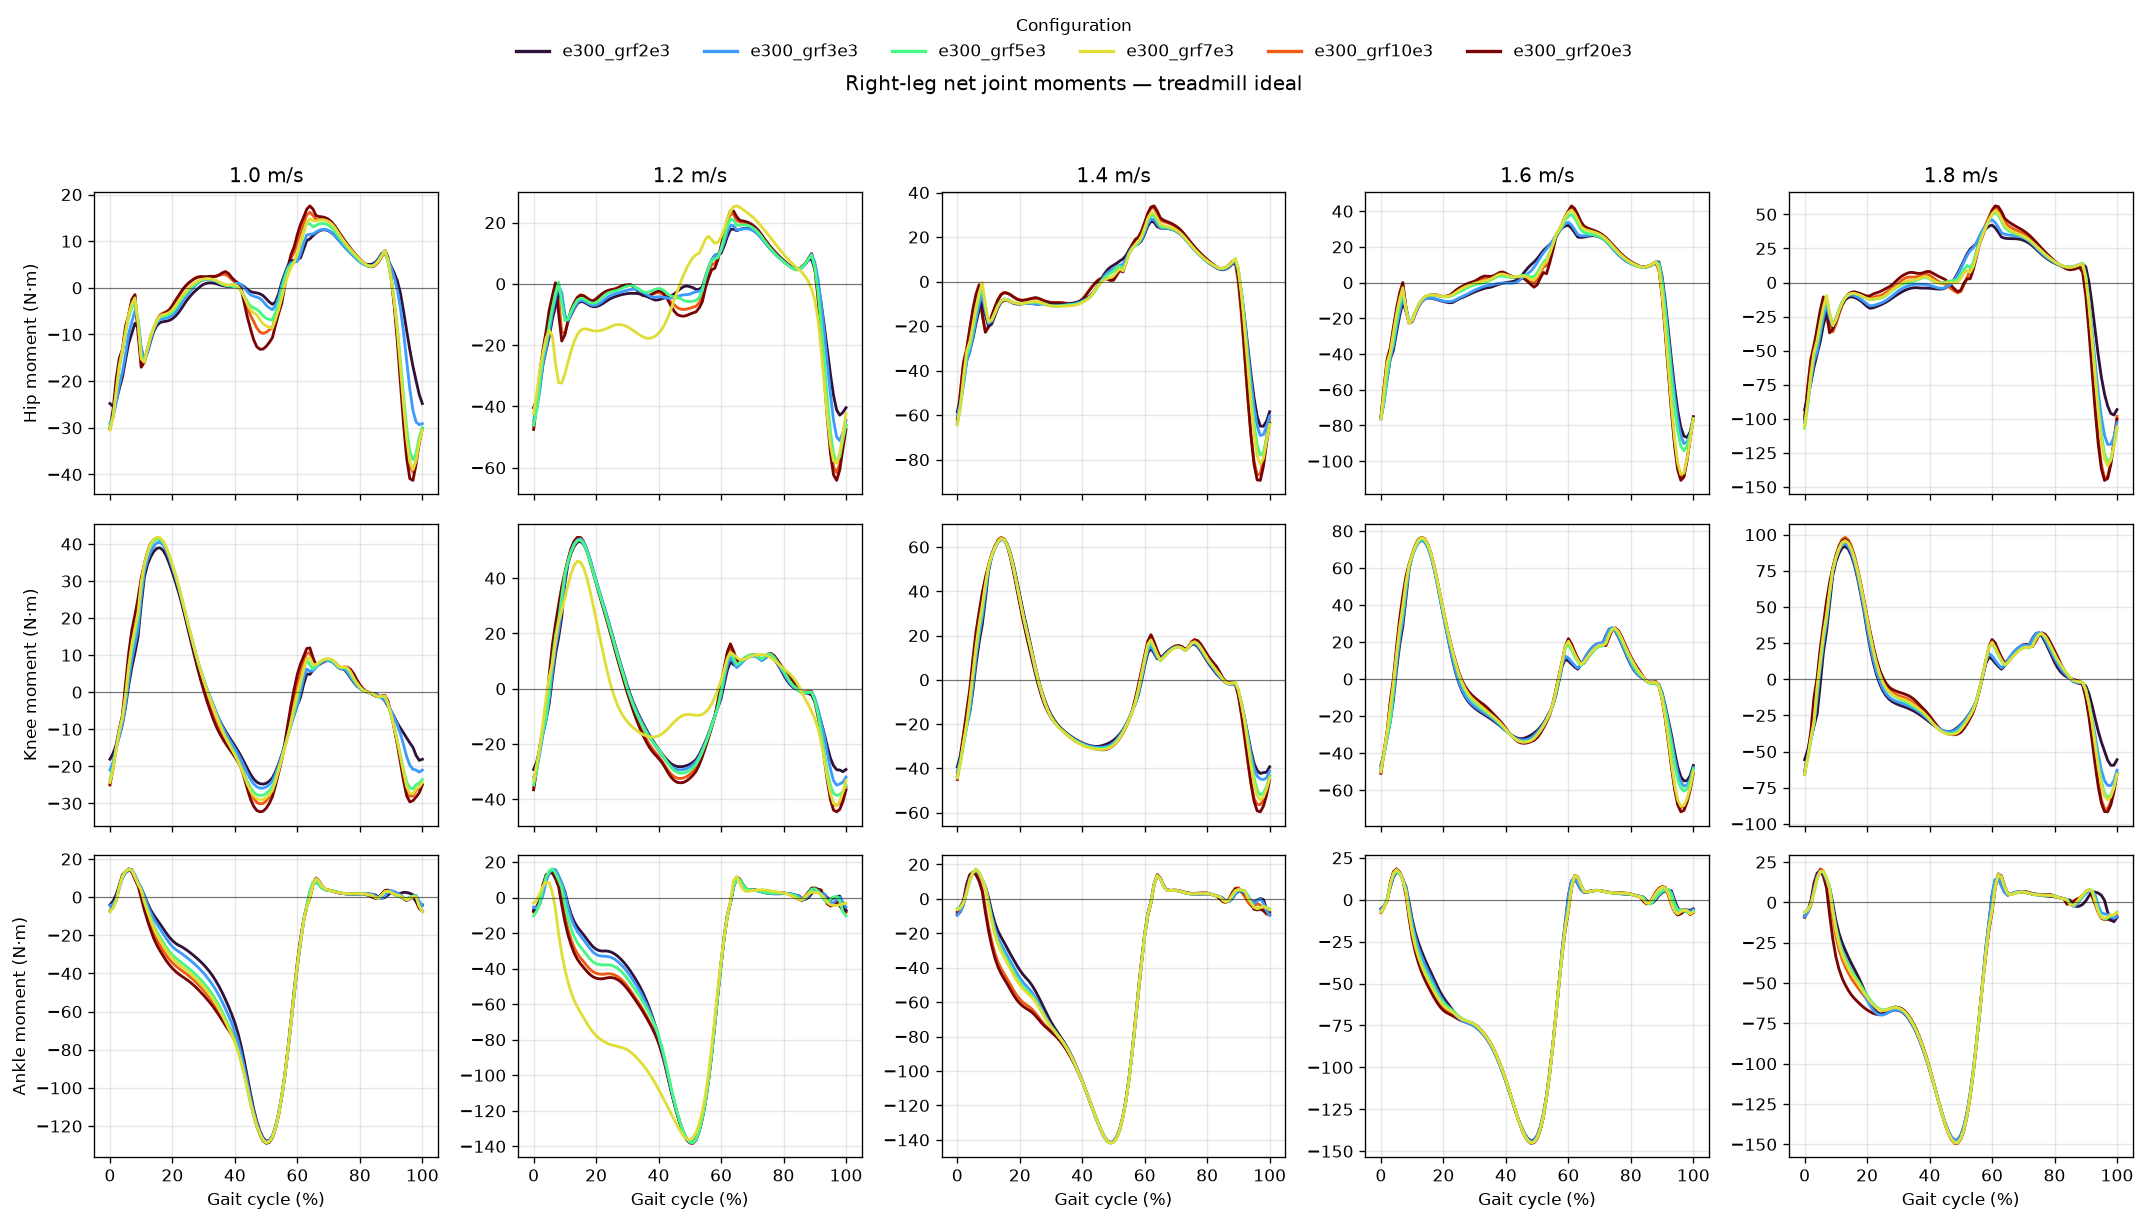

In [21]:
_moment_cache = {}

def calculate_joint_moments(record):
    key = str(record['path'])
    if key in _moment_cache:
        return _moment_cache[key]
    model = get_model(record)
    states = record.states
    def actuator_force(state):
        full = state.replace(
            qdd=jnp.zeros(model.accs.n), tau=jnp.zeros(model.tau.n),
            ext_forces=jnp.zeros(model.ext_forces.n), ext_torques=jnp.zeros(model.ext_torques.n),
        )
        return model.run['actuator_model'](full, model.default_constants)
    moments = np.asarray(jax.vmap(actuator_force)(states)).reshape(len(states), -1)
    output = moments, list(model.tau.names)
    _moment_cache[key] = output
    return output

def moment_index(names, joint, side='r'):
    for candidate in (f't_{joint}_{side}', f'M_{joint}_{side}'):
        if candidate in names:
            return names.index(candidate)
    raise KeyError(f'Could not resolve the {joint}_{side} moment in {names}')

def plot_right_joint_moments_by_speed(stage):
    chosen = results[results.stage == stage].sort_values(['speed', 'configuration'])
    colors = configuration_colors()
    joints = ('hip', 'knee', 'ankle')
    speeds = sorted(chosen.speed.unique())
    fig, axes = plt.subplots(len(joints), len(speeds), figsize=(18, 10), sharex=True)
    for row, joint in enumerate(joints):
        for col, speed in enumerate(speeds):
            axis = axes[row, col]
            for _, record in chosen[np.isclose(chosen.speed, speed)].iterrows():
                moments, names = calculate_joint_moments(record)
                axis.plot(gait_cycle(len(moments)), moments[:, moment_index(names, joint)], color=colors[record.configuration], linewidth=1.7)
            axis.axhline(0, color='black', linewidth=.7, alpha=.5)
            if row == 0: axis.set_title(f'{speed:.1f} m/s')
            if col == 0: axis.set_ylabel(f'{joint.title()} moment (N·m)')
            if row == len(joints) - 1: axis.set_xlabel('Gait cycle (%)')
            axis.grid(alpha=.3)
    config_handles = [Line2D([0], [0], color=colors[name], lw=2, label=name) for name in RESULT_FOLDERS]
    fig.legend(handles=config_handles, title='Configuration', loc='upper center', bbox_to_anchor=(.5, 1.02), ncol=len(config_handles), frameon=False)
    fig.suptitle(f'Right-leg net joint moments — {stage.replace("_", " ")}', y=.96)
    fig.tight_layout(rect=(0, 0, 1, .93)); return fig

plot_right_joint_moments_by_speed(STAGE);

## Slip and friction overlay

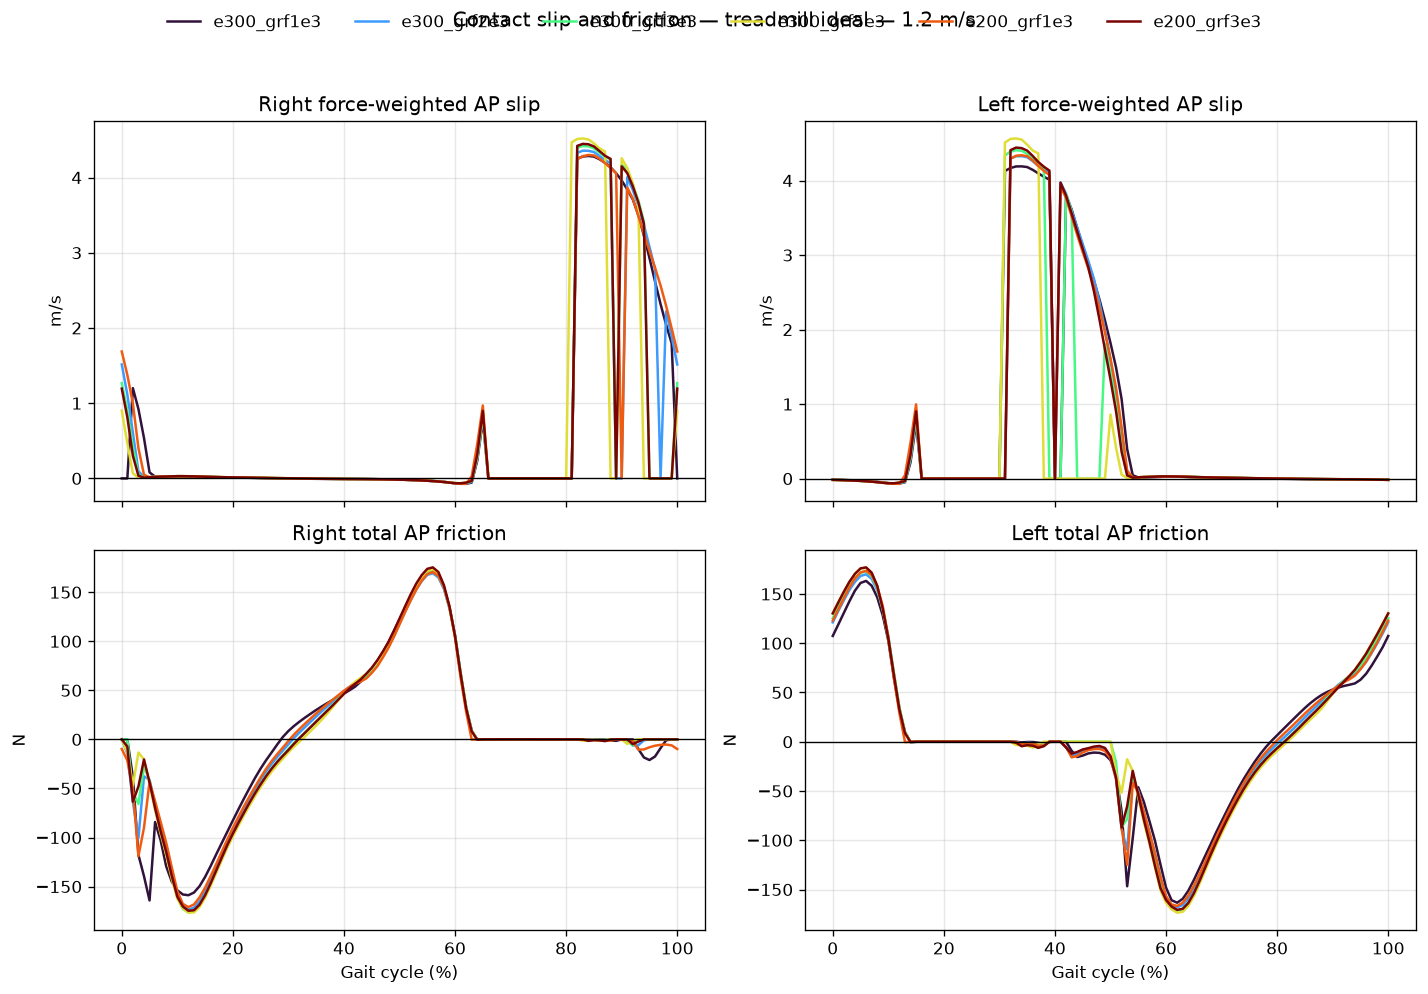

In [10]:
def plot_slip_friction_overlay(stage, speed):
    chosen = select(stage, speed)
    colors = configuration_colors()
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    for _, record in chosen.iterrows():
        names, sides, slip, friction, normal = evaluate_contact_diagnostics(get_model(record), record.states, float(record.globals.dur))
        normal = np.maximum(normal, 0)
        x = gait_cycle(len(record.states))
        for side in (0, 1):
            mask = sides == side
            weights = normal[:, mask]
            denominator = weights.sum(axis=1)
            numerator = (slip[:, mask, 0] * weights).sum(axis=1)
            weighted = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator > 1e-8)
            total_friction = friction[:, mask, 0].sum(axis=1)
            axes[0, side].plot(x, weighted, color=colors[record.configuration], label=record.configuration)
            axes[1, side].plot(x, total_friction, color=colors[record.configuration], label=record.configuration)
    for col, side in enumerate(('Right', 'Left')):
        axes[0, col].set_title(f'{side} force-weighted AP slip'); axes[0, col].set_ylabel('m/s')
        axes[1, col].set_title(f'{side} total AP friction'); axes[1, col].set_ylabel('N'); axes[1, col].set_xlabel('Gait cycle (%)')
    for axis in axes.ravel(): axis.axhline(0, color='black', linewidth=.8); axis.grid(alpha=.3)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='outside upper center', ncol=len(labels), frameon=False)
    fig.suptitle(f'Contact slip and friction — {stage.replace("_", " ")} — {speed:.1f} m/s', y=1.03)
    fig.tight_layout(); return fig

plot_slip_friction_overlay(STAGE, SPEED);

## Absolute durations: ideal and realistic

In [22]:
from IPython.display import display

def absolute_duration_table(stage):
    chosen = results[results.stage == stage]
    duration_data = chosen.assign(duration=chosen.globals.map(lambda value: abs(float(value.dur))))
    table = duration_data.pivot_table(
        index='speed', columns='configuration', values='duration', aggfunc='first',
    ).sort_index()
    experimental = pd.Series(
        {speed: abs(get_duration(DEFAULT_GAIT_DATA_FILE, PARTICIPANT, speed)) for speed in table.index},
        name='Experimental',
    )
    output = pd.concat([experimental, table], axis=1)
    output.index.name = 'Speed (m/s)'
    output.columns.name = None
    return output

ideal_duration_table = absolute_duration_table('treadmill_ideal')
#realistic_duration_table = absolute_duration_table('treadmill_realistic')

def highlight_closest_durations(row):
    styles = pd.Series('', index=row.index)
    errors = row.drop(labels='Experimental').dropna().sub(row['Experimental']).abs().sort_values()
    if len(errors) >= 1:
        styles[errors.index[0]] = 'background-color: #b7e4c7; color: black'
    if len(errors) >= 2:
        styles[errors.index[1]] = 'background-color: #fff3b0; color: black'
    return styles

def styled_duration_table(table):
    return table.style.format('{:.4f}').apply(highlight_closest_durations, axis=1)

print('Ideal treadmill duration (s)')
display(styled_duration_table(ideal_duration_table))
print('Realistic treadmill duration (s)')
display(styled_duration_table(realistic_duration_table))

Ideal treadmill duration (s)


,Experimental,e300_grf10e3,e300_grf20e3,e300_grf2e3,e300_grf3e3,e300_grf5e3,e300_grf7e3
Speed (m/s),,,,,,,
1.000000,1.2260,1.0957,1.0998,1.0811,1.0902,1.0908,1.0922
1.200000,1.1560,0.9718,0.9721,0.9712,0.9807,0.9713,0.9643
1.400000,1.1010,0.8744,0.8737,0.8782,0.8778,0.8827,0.8854
1.600000,1.0330,0.8167,0.8179,0.8136,0.8116,0.8139,0.8157
1.800000,0.9920,0.7643,0.7479,0.7534,0.7545,0.7590,0.7591


Realistic treadmill duration (s)


NameError: name 'realistic_duration_table' is not defined

## Effort contribution to the objective (%)

Each value is 100 × effort weight × re-evaluated effort term / saved IPOPT objective.

In [23]:
from biosym.objectives.effort_term import Objective as EffortObjective

_raw_effort_cache = {}
_effort_percent_cache = {}

def raw_effort(record):
    key = str(record['path'])
    if key not in _raw_effort_cache:
        specification = next(item for item in record['settings']['objectives'] if item['name'] == 'effort_term')
        objective = EffortObjective(get_model(record), record['settings'], **dict(specification.get('args', {})))
        _raw_effort_cache[key] = float(jax.device_get(objective.get_objfun()(record['states'], record['globals'])))
    return _raw_effort_cache[key]

def effort_percent(record):
    key = str(record['path'])
    if key in _effort_percent_cache:
        return _effort_percent_cache[key]
    specification = next(item for item in record['settings']['objectives'] if item['name'] == 'effort_term')
    weighted_effort = float(specification.get('weight', 1.0)) * raw_effort(record)
    saved_objective = float(record['info']['obj_val'])
    percentage = 100.0 * weighted_effort / saved_objective if saved_objective != 0 else np.nan
    _effort_percent_cache[key] = percentage
    return percentage

def effort_percentage_table(stage):
    chosen = results[results.stage == stage].copy()
    chosen['effort percentage'] = chosen.apply(effort_percent, axis=1)
    table = chosen.pivot_table(
        index='speed', columns='configuration', values='effort percentage', aggfunc='first',
    ).sort_index()
    table.index.name = 'Speed (m/s)'
    table.columns.name = None
    return table

def raw_effort_table(stage):
    chosen = results[results.stage == stage].copy()
    chosen['raw effort'] = chosen.apply(raw_effort, axis=1)
    table = chosen.pivot_table(
        index='speed', columns='configuration', values='raw effort', aggfunc='first',
    ).sort_index()
    table.index.name = 'Speed (m/s)'
    table.columns.name = None
    return table

ideal_effort_percentage_table = effort_percentage_table('treadmill_ideal')
#realistic_effort_percentage_table = effort_percentage_table('treadmill_realistic')
ideal_raw_effort_table = raw_effort_table('treadmill_ideal')
#realistic_raw_effort_table = raw_effort_table('treadmill_realistic')

print('Ideal treadmill: effort contribution to objective (%)')
display(ideal_effort_percentage_table.style.format('{:.2f}%'))
#print('Realistic treadmill: effort contribution to objective (%)')
#display(realistic_effort_percentage_table.style.format('{:.2f}%'))
print('Ideal treadmill: raw effort objective value (before objective weight)')
display(ideal_raw_effort_table.style.format('{:.6g}'))
#print('Realistic treadmill: raw effort objective value (before objective weight)')
#display(realistic_raw_effort_table.style.format('{:.6g}'))

Ideal treadmill: effort contribution to objective (%)


,e300_grf10e3,e300_grf20e3,e300_grf2e3,e300_grf3e3,e300_grf5e3,e300_grf7e3
Speed (m/s),,,,,,
1.000000,76.24%,70.35%,77.60%,77.18%,77.13%,76.03%
1.200000,74.90%,67.13%,78.33%,77.70%,78.71%,87.20%
1.400000,76.69%,68.71%,80.73%,79.46%,76.89%,74.40%
1.600000,72.78%,64.73%,76.82%,75.10%,75.35%,75.50%
1.800000,66.24%,64.30%,70.40%,70.28%,70.39%,67.16%


Ideal treadmill: raw effort objective value (before objective weight)


,e300_grf10e3,e300_grf20e3,e300_grf2e3,e300_grf3e3,e300_grf5e3,e300_grf7e3
Speed (m/s),,,,,,
1.000000,0.00938811,0.00983896,0.00774827,0.00809335,0.00863555,0.00891682
1.200000,0.0142815,0.0148837,0.0117925,0.012369,0.0134892,0.0328858
1.400000,0.0200354,0.0206216,0.0169748,0.0175442,0.0182682,0.0187267
1.600000,0.0277014,0.0284881,0.0235439,0.0243288,0.0260576,0.0272168
1.800000,0.0377308,0.0407276,0.0306166,0.0327994,0.0352898,0.0361146
